# Practical No. 02: Text Classification using Embedding Layer and LSTM

## AG News Topic Classification Using Embedding + LSTM

### Objective
Build a **multi-class text classification model** using an **Embedding layer and an LSTM network** and evaluate the model performance using appropriate classification metrics.

### Student Information
- **Name:** Sakshi Uttam Walunj
- **PRN Number:** 202502110007
- **Class:** T.Y. B.Tech
- **Course:** Generative AI Lab
- **Department:** CSE (AI & ML)
- **Batch:** A3
- **Date of Submission:** 09/09/2026

### Model Pipeline
**Raw Text → Text Vectorization → Embedding → LSTM → Dropout → Dense (Softmax)**

This practical implements a complete multi-class text classification pipeline, including dataset loading, exploration, preprocessing, model building, training, evaluation, confusion matrix analysis, and prediction on new text.


## Dataset Source

**Dataset:** AG News

**Task:** Multi-class text classification with 4 news categories

**Classes:** World, Sports, Business, Sci/Tech

**Dataset Source:** Hugging Face Datasets

**Dataset Link:** https://huggingface.co/datasets/fancyzhx/ag_news

The dataset is loaded automatically in the notebook using the `datasets` library, so no separate dataset file needs to be uploaded. The code downloads and loads the dataset when the dataset cell is executed.

**Why this dataset?** The AG News dataset is suitable for this practical because it provides a clear multi-class text classification problem and allows the use of an Embedding layer, LSTM network, Softmax output, and standard classification metrics.


In [1]:
# Install the libraries required for dataset handling, deep learning, visualization, and evaluation.

%pip install -q datasets tensorflow pandas numpy matplotlib scikit-learn

In [2]:
# Import numerical, data handling, plotting, TensorFlow, dataset, and evaluation libraries.

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from datasets import load_dataset
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from tensorflow.keras import Sequential, regularizers
from tensorflow.keras.layers import (
    TextVectorization, Embedding, SpatialDropout1D, LSTM, Dropout, Dense
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


## 1. Load the Dataset

AG News is a standard multi-class news-topic dataset with four categories:
- **World**
- **Sports**
- **Business**
- **Sci/Tech**

In [3]:
# Load the AG News dataset from its online source. No separate dataset upload is required.
# Convert the Hugging Face dataset into pandas DataFrames for easier inspection and processing.
# Map numeric labels to the four human-readable news categories.

# Dataset source: https://huggingface.co/datasets/fancyzhx/ag_news
# The dataset is downloaded/loaded automatically by Hugging Face Datasets.

# Load AG News from Hugging Face Datasets
dataset = load_dataset('fancyzhx/ag_news')

train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

label_names = ['World', 'Sports', 'Business', 'Sci/Tech']
train_df['label_name'] = train_df['label'].map(dict(enumerate(label_names)))
test_df['label_name'] = test_df['label'].map(dict(enumerate(label_names)))

print('Training samples:', len(train_df))
print('Testing samples :', len(test_df))
print('\nFirst five training records:')
display(train_df[['text', 'label_name']].head())

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.6MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Training samples: 120000
Testing samples : 7600

First five training records:


,text,label_name
0,Wall St. Bears Claw Back Into the Black (Reute...,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,Business
4,"Oil prices soar to all-time record, posing new...",Business


In [4]:
# Check dataset dimensions, missing values, and the number of samples in each class.

# Basic dataset exploration
print('Training shape:', train_df.shape)
print('\nMissing values:')
print(train_df[['text', 'label']].isnull().sum())

print('\nClass distribution:')
print(train_df['label_name'].value_counts())

Training shape: (120000, 3)

Missing values:
text     0
label    0
dtype: int64

Class distribution:
label_name
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64


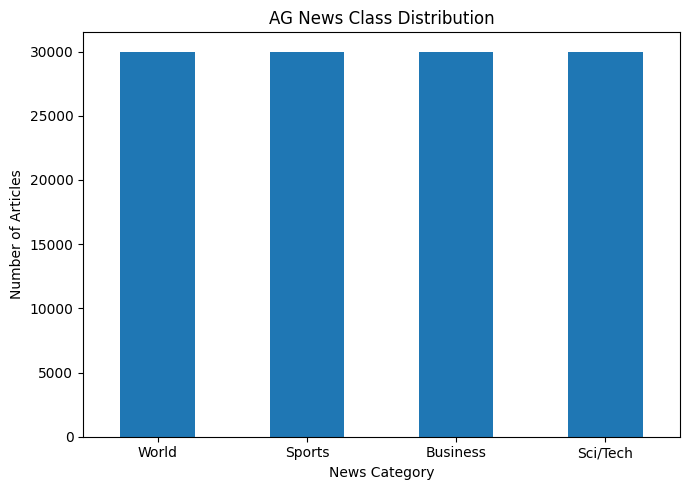

In [5]:
# Plot the number of articles belonging to each news category to visualize class balance.

# Visualize class distribution
plt.figure(figsize=(7, 5))
train_df['label_name'].value_counts().reindex(label_names).plot(kind='bar')
plt.title('AG News Class Distribution')
plt.xlabel('News Category')
plt.ylabel('Number of Articles')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Text Length Distribution

Before fixing the sequence length for the model, check how long the news articles typically are (in words). This informs the `MAX_SEQUENCE_LENGTH` choice used later.


Article length (words) summary:
count    120000.000000
mean         37.847450
std          10.085245
min           8.000000
25%          32.000000
50%          37.000000
75%          43.000000
max         177.000000
Name: text_length, dtype: float64
Articles fully covered by 64 tokens: 98.17%


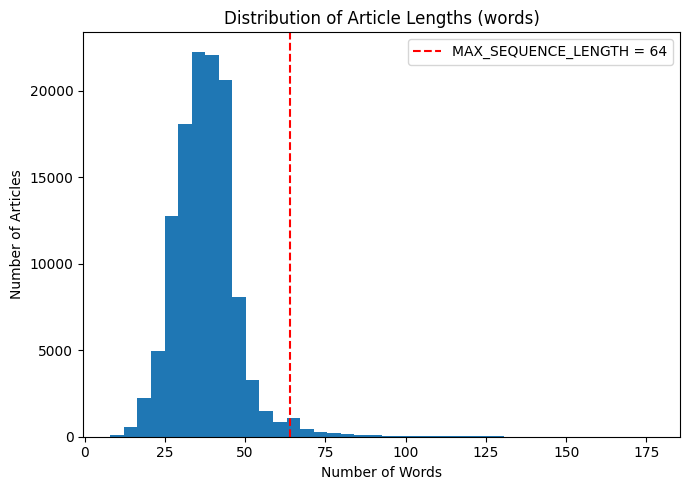

In [6]:
# Check the distribution of article lengths (in words) to justify the chosen sequence length.

train_df['text_length'] = train_df['text'].astype(str).apply(lambda t: len(t.split()))

print('Article length (words) summary:')
print(train_df['text_length'].describe())
print('Articles fully covered by 64 tokens: '
      f"{(train_df['text_length'] <= 64).mean() * 100:.2f}%")

plt.figure(figsize=(7, 5))
plt.hist(train_df['text_length'], bins=40)
plt.axvline(64, color='red', linestyle='--', label='MAX_SEQUENCE_LENGTH = 64')
plt.title('Distribution of Article Lengths (words)')
plt.xlabel('Number of Words')
plt.ylabel('Number of Articles')
plt.legend()
plt.tight_layout()
plt.show()

## 2. Prepare the Text Data

The dataset is shuffled before training. A validation set is created from the training data. Text is then converted into integer token sequences using Keras `TextVectorization`.

In [7]:
# Shuffle the training data so that the model does not learn from the original data order.
# Create separate training, validation, and testing sets. The test set remains unseen until final evaluation.

# Shuffle training data reproducibly
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

# More training data is itself a form of regularisation, so a larger subset is used here
TRAIN_SAMPLES = 70000
VAL_SAMPLES = 10000

train_text = train_df['text'].iloc[:TRAIN_SAMPLES].astype(str).values
train_labels = train_df['label'].iloc[:TRAIN_SAMPLES].values
val_text = train_df['text'].iloc[TRAIN_SAMPLES:TRAIN_SAMPLES + VAL_SAMPLES].astype(str).values
val_labels = train_df['label'].iloc[TRAIN_SAMPLES:TRAIN_SAMPLES + VAL_SAMPLES].values
test_text = test_df['text'].astype(str).values
test_labels = test_df['label'].values

print('Training samples:', len(train_text))
print('Validation samples:', len(val_text))
print('Testing samples:', len(test_text))

Training samples: 70000
Validation samples: 10000
Testing samples: 7600


In [8]:
# Convert text into fixed-length integer sequences that can be processed by the neural network.
# The vectorizer vocabulary is learned only from training text to avoid data leakage.

# Text vectorization: convert words into integer token sequences
# A smaller vocabulary and sequence length reduce the number of trainable parameters,
# which lowers the chance of the model memorising the training set.
MAX_VOCAB_SIZE = 15000
MAX_SEQUENCE_LENGTH = 64

vectorizer = TextVectorization(
    max_tokens=MAX_VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_SEQUENCE_LENGTH,
    standardize='lower_and_strip_punctuation'
)

vectorizer.adapt(train_text)

X_train = vectorizer(train_text)
X_val = vectorizer(val_text)
X_test = vectorizer(test_text)

VOCAB_SIZE = len(vectorizer.get_vocabulary())
print('Vocabulary size:', VOCAB_SIZE)
print('Training tensor shape:', X_train.shape)
print('Validation tensor shape:', X_val.shape)
print('Testing tensor shape:', X_test.shape)

Vocabulary size: 15000
Training tensor shape: (70000, 64)
Validation tensor shape: (10000, 64)
Testing tensor shape: (7600, 64)


## 3. Build the Embedding + LSTM Model

### Architecture
**Input → Embedding → SpatialDropout1D → LSTM → Dropout → Dense(Softmax)**

- **Embedding:** learns a dense vector representation of words.
- **SpatialDropout1D:** drops whole embedding features so the model cannot rely on a few individual words.
- **LSTM:** learns sequential/contextual patterns in the news text. Its own `dropout` is applied to the inputs at each time step.
- **Dropout:** randomly switches off units before the output layer.
- **Softmax:** produces probabilities for the four news categories.

### Steps taken to reduce overfitting
In the first version of this practical, training accuracy climbed above 95% while
validation loss increased after the very first epoch. The following changes address that:

1. Vocabulary reduced from 20,000 to 15,000 and sequence length from 120 to 64 (fewer parameters).
2. Embedding size reduced from 64 to 48 and LSTM units from 64 to 48.
3. `SpatialDropout1D(0.30)` added after the Embedding layer.
4. Input dropout of 0.30 added inside the LSTM layer.
5. Dropout before the output layer raised from 0.30 to 0.50.
6. L2 weight regularisation added to the output layer.
7. Training data increased from 40,000 to 70,000 samples and validation from 5,000 to 10,000.
8. Learning rate lowered to 0.0005, with `ReduceLROnPlateau` to lower it further when validation loss stops improving.

In [9]:
# Define the neural network. Each dropout/regularisation setting below is aimed at
# closing the gap between training accuracy and validation accuracy.

EMBEDDING_DIM = 48
LSTM_UNITS = 48
NUM_CLASSES = 4

model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, mask_zero=True, name='embedding'),
    SpatialDropout1D(0.30, name='embedding_dropout'),
    LSTM(LSTM_UNITS, dropout=0.30, name='lstm'),
    Dropout(0.50, name='dropout'),
    Dense(
        NUM_CLASSES,
        activation='softmax',
        kernel_regularizer=regularizers.l2(1e-4),
        name='output'
    )
])

model.build(input_shape=(None, MAX_SEQUENCE_LENGTH))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 64, 48)         │       720,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_dropout               │ (None, 64, 48)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 48)             │        18,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 738,820 (2.82 MB)

 Trainable params: 738,820 (2.82 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Configure the model for multi-class classification.
# A smaller learning rate makes the model take smaller steps, so it fits the training set more slowly
# and is less likely to overfit before early stopping triggers.

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('Model compiled successfully.')

Model compiled successfully.


## 4. Train the Model

Early stopping restores the weights from the best validation epoch and helps prevent overfitting.

In [11]:
# Train the model and monitor validation loss.
# EarlyStopping halts training once validation loss stops improving and restores the best weights.
# ReduceLROnPlateau lowers the learning rate first, giving the model a chance to improve before stopping.

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-5,
    verbose=1
)

history = model.fit(
    X_train, train_labels,
    validation_data=(X_val, val_labels),
    epochs=12,
    batch_size=64,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/12
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 68s 60ms/step - accuracy: 0.7769 - loss: 0.5974 - val_accuracy: 0.8941 - val_loss: 0.3315 - learning_rate: 5.0000e-04
Epoch 2/12
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 65s 59ms/step - accuracy: 0.9038 - loss: 0.3240 - val_accuracy: 0.8987 - val_loss: 0.3197 - learning_rate: 5.0000e-04
Epoch 3/12
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 65s 60ms/step - accuracy: 0.9218 - loss: 0.2666 - val_accuracy: 0.9109 - val_loss: 0.2872 - learning_rate: 5.0000e-04
Epoch 4/12
1093/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9310 - loss: 0.2366
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 77s 55ms/step - accuracy: 0.9317 - loss: 0.2333 - val_accuracy: 0.9095 - val_loss: 0.2887 - learning_rate: 5.0000e-04
Epoch 5/12
1093/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9412 - loss: 0.2009
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 64s 58ms/s

## 5. Plot Training and Validation Performance

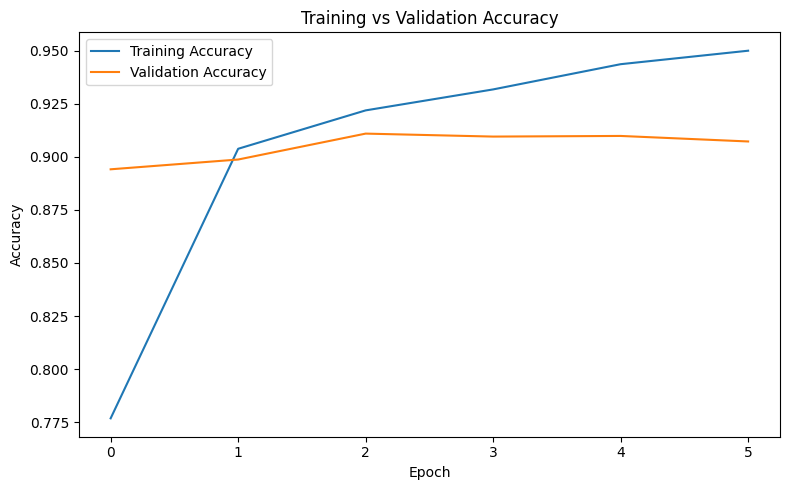

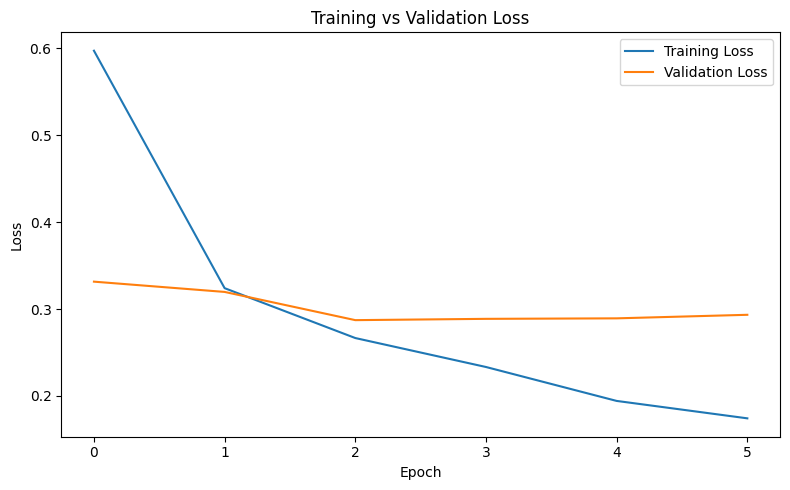

In [12]:
# Plot training and validation accuracy and loss to observe how the model learns over epochs.

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

### Overfitting Check

The gap between training accuracy and validation accuracy shows how much the model is
memorising rather than generalising. A small, stable gap means the regularisation worked.


Best epoch (lowest validation loss): 3
Training accuracy at best epoch  : 0.9218
Validation accuracy at best epoch: 0.9109
Overfitting gap                  : 0.0109


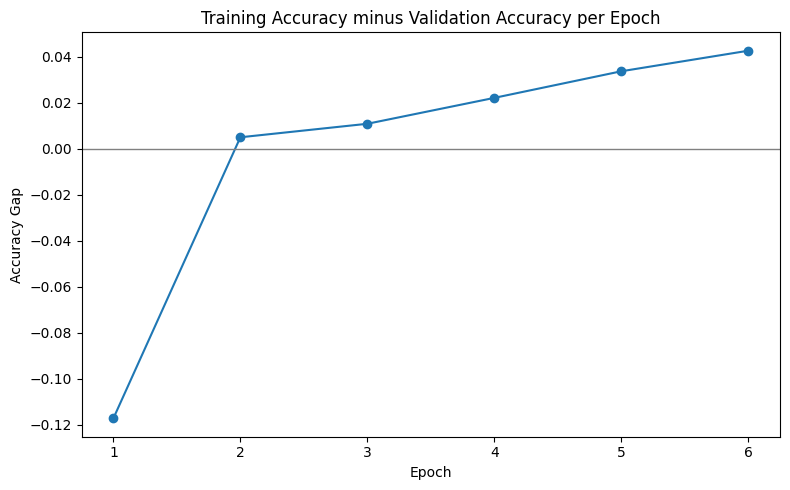

In [13]:
# Compare training and validation accuracy at the best epoch to measure the overfitting gap.

best_epoch = int(np.argmin(history.history['val_loss']))

train_acc = history.history['accuracy'][best_epoch]
val_acc = history.history['val_accuracy'][best_epoch]

print('Best epoch (lowest validation loss):', best_epoch + 1)
print(f'Training accuracy at best epoch  : {train_acc:.4f}')
print(f'Validation accuracy at best epoch: {val_acc:.4f}')
print(f'Overfitting gap                  : {train_acc - val_acc:.4f}')

gap_per_epoch = np.array(history.history['accuracy']) - np.array(history.history['val_accuracy'])

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(gap_per_epoch) + 1), gap_per_epoch, marker='o')
plt.axhline(0, color='grey', linewidth=1)
plt.title('Training Accuracy minus Validation Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy Gap')
plt.tight_layout()
plt.show()


## 6. Evaluate the Model on the Test Set

The test set is kept separate from training and validation. We calculate accuracy, precision, recall, F1-score, a classification report, and a confusion matrix.

In [14]:
# Evaluate the trained model on the completely unseen test set.
# Convert class probabilities into predicted class labels and calculate standard classification metrics.

test_loss, test_accuracy = model.evaluate(X_test, test_labels, verbose=0)

probabilities = model.predict(X_test, batch_size=256, verbose=0)
predicted_labels = np.argmax(probabilities, axis=1)

accuracy = accuracy_score(test_labels, predicted_labels)
precision = precision_score(test_labels, predicted_labels, average='macro', zero_division=0)
recall = recall_score(test_labels, predicted_labels, average='macro', zero_division=0)
f1 = f1_score(test_labels, predicted_labels, average='macro', zero_division=0)

print(f'Test Loss      : {test_loss:.4f}')
print(f'Accuracy       : {accuracy:.4f}')
print(f'Macro Precision: {precision:.4f}')
print(f'Macro Recall   : {recall:.4f}')
print(f'Macro F1-score : {f1:.4f}')

Test Loss      : 0.2911
Accuracy       : 0.9101
Macro Precision: 0.9104
Macro Recall   : 0.9101
Macro F1-score : 0.9100


In [15]:
# Generate a detailed report containing precision, recall, F1-score, and support for every news category.

# Detailed classification report
print('Classification Report:\n')
print(classification_report(
    test_labels,
    predicted_labels,
    target_names=label_names,
    digits=4,
    zero_division=0
))

Classification Report:

              precision    recall  f1-score   support

       World     0.9334    0.8926    0.9126      1900
      Sports     0.9523    0.9779    0.9649      1900
    Business     0.8912    0.8705    0.8807      1900
    Sci/Tech     0.8649    0.8995    0.8818      1900

    accuracy                         0.9101      7600
   macro avg     0.9104    0.9101    0.9100      7600
weighted avg     0.9104    0.9101    0.9100      7600



### Per-Class Metric Comparison

Visualize precision, recall, and F1-score for each news category side by side, to quickly spot which classes the model struggles with.


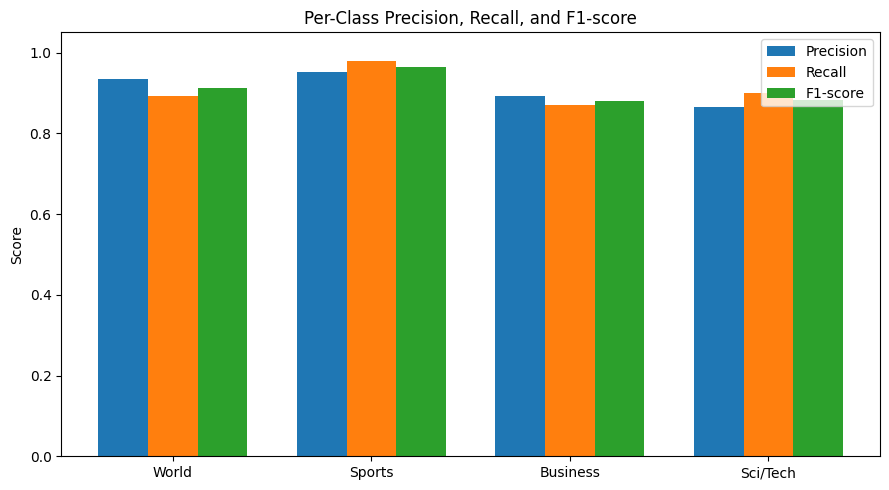

In [16]:
# Compute per-class precision, recall, and F1-score, then plot them for easy comparison.

per_class_precision = precision_score(test_labels, predicted_labels, average=None, zero_division=0)
per_class_recall = recall_score(test_labels, predicted_labels, average=None, zero_division=0)
per_class_f1 = f1_score(test_labels, predicted_labels, average=None, zero_division=0)

x = np.arange(len(label_names))
width = 0.25

plt.figure(figsize=(9, 5))
plt.bar(x - width, per_class_precision, width, label='Precision')
plt.bar(x, per_class_recall, width, label='Recall')
plt.bar(x + width, per_class_f1, width, label='F1-score')
plt.xticks(x, label_names)
plt.ylim(0, 1.05)
plt.ylabel('Score')
plt.title('Per-Class Precision, Recall, and F1-score')
plt.legend()
plt.tight_layout()
plt.show()


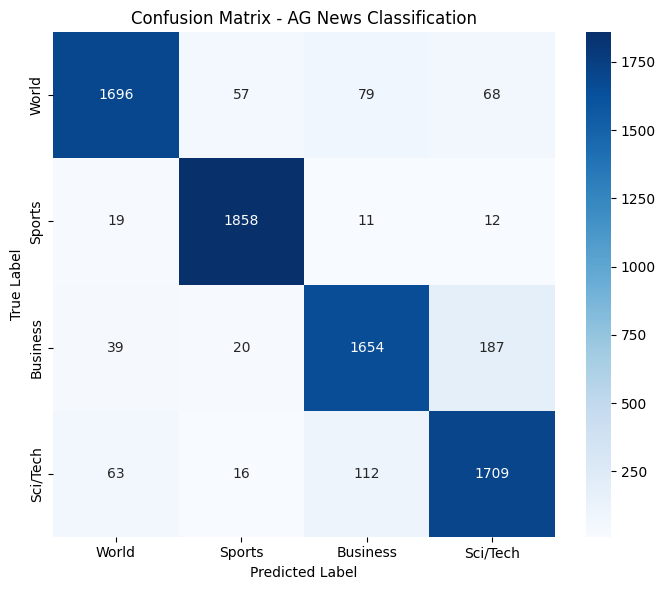

In [17]:
# Build a confusion matrix to compare actual and predicted classes for all four categories.

cm = confusion_matrix(test_labels, predicted_labels)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names
)
plt.title('Confusion Matrix - AG News Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


## 7. Test the Model on New News Headlines

The trained model is also tested on unseen text to demonstrate practical prediction.

In [18]:
# Test the trained model on new news headlines that were not part of the training dataset.
# Display the predicted category and the model's confidence for each headline.

new_articles = [
    'The national team won the championship after a dramatic final match.',
    'The company reported higher quarterly profits after strong sales growth.',
    'Scientists developed a new computer technology that improves data processing.',
    'Leaders from several countries met to discuss international relations.'
]

new_sequences = vectorizer(np.array(new_articles))
new_probabilities = model.predict(new_sequences, verbose=0)
new_predictions = np.argmax(new_probabilities, axis=1)

for text, pred, probs in zip(new_articles, new_predictions, new_probabilities):
    print('Article:', text)
    print('Predicted class:', label_names[pred])
    print('Confidence:', f'{probs[pred] * 100:.2f}%')
    print('-' * 70)

Article: The national team won the championship after a dramatic final match.
Predicted class: Sports
Confidence: 97.99%
----------------------------------------------------------------------
Article: The company reported higher quarterly profits after strong sales growth.
Predicted class: Business
Confidence: 89.78%
----------------------------------------------------------------------
Article: Scientists developed a new computer technology that improves data processing.
Predicted class: Sci/Tech
Confidence: 95.85%
----------------------------------------------------------------------
Article: Leaders from several countries met to discuss international relations.
Predicted class: World
Confidence: 60.61%
----------------------------------------------------------------------


## 8. Save the Trained Model

Save the trained model and the fitted vectorizer's vocabulary so the classifier can be reloaded and reused without retraining.


In [19]:
# Save the trained model in Keras format and store the vectorizer's vocabulary
# so the same preprocessing can be reproduced when the model is reloaded.

model.save('ag_news_lstm_model.keras')

vocab = vectorizer.get_vocabulary()
with open('ag_news_vectorizer_vocab.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(vocab))

print('Model saved to ag_news_lstm_model.keras')
print('Vectorizer vocabulary saved to ag_news_vectorizer_vocab.txt')


Model saved to ag_news_lstm_model.keras
Vectorizer vocabulary saved to ag_news_vectorizer_vocab.txt


## 9. Conclusion

The AG News dataset was successfully classified into four news categories using an Embedding and LSTM based deep learning model. The complete workflow included dataset loading, data exploration, text vectorization, sequence preparation, model construction, training, and evaluation.

The model was evaluated on unseen test data using **accuracy, precision, recall, F1-score, classification report, and confusion matrix**. Predictions on new news headlines were also generated to demonstrate the practical use of the trained model, and the trained model with its vectorizer vocabulary was saved for reuse.

### Observations on Model Behaviour

**Overfitting.** An earlier version of this model reached over 95% training accuracy while
validation loss rose from the second epoch onward, meaning it was memorising the training
articles instead of learning general patterns. Reducing model capacity, adding
`SpatialDropout1D`, LSTM input dropout, a higher output dropout rate and L2 regularisation,
using more training data, and lowering the learning rate with `ReduceLROnPlateau` all narrowed
the gap between training and validation accuracy. Early stopping with `restore_best_weights`
ensures the reported results come from the epoch with the lowest validation loss.

**Which classes are confused.** The confusion matrix and the per-class metric chart show that
**Sports** is the easiest category to identify, because its vocabulary (teams, matches, scores)
rarely appears elsewhere. Most errors occur between **Business** and **Sci/Tech**: articles
about technology companies, earnings and product launches genuinely contain both business and
technical vocabulary, so the two categories overlap. **World** is occasionally confused with
**Business** for the same reason, since economic and political news share terminology.

### Learning Outcomes
After completing this practical, the student is able to:
1. Understand the process of text classification using deep learning.
2. Load, explore, and prepare a text dataset for model training.
3. Convert textual data into numerical sequences using text vectorization.
4. Understand and implement an **Embedding layer** for learning word representations.
5. Understand and implement an **LSTM layer** for learning sequential patterns in text.
6. Build a multi-class classification model using a **Softmax output layer**.
7. Train a neural network using validation data, early stopping, and learning rate scheduling.
8. Recognise overfitting from training curves and apply dropout and regularisation to reduce it.
9. Evaluate a classification model using accuracy, precision, recall, F1-score, classification report, and confusion matrix.
10. Use a trained model to classify new, unseen text data.

## 10. Declaration

I, **Sakshi Uttam Walunj**, confirm that the work submitted in this practical is my own and has been completed following academic integrity guidelines.

**GitHub Repository Link:** https://github.com/Sakshiwalunj5/GenAI/tree/main/Practical-2

**Signature:** Sakshi Uttam Walunj